In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns

In [2]:
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
cars.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [3]:
X_list = cars.wt.values
X_np = np.array(X_list,dtype = np.float32).reshape(-1,1)
y_list = cars.mpg.values
y_np = np.array(y_list,dtype = np.float32).reshape(-1,1)
X = torch.from_numpy(X_np)
y_true = torch.from_numpy(y_np)

## **Model (class)**

In [4]:
class LinearRegressionTorch(nn.Module):
    def __init__(self,input_size, output_size):
        super(LinearRegressionTorch,self).__init__()
        self.linear = nn.Linear(input_size,output_size)
        
    def forward(self,X):
        out = self.linear(X)
        return out
input_dim =1
output_dim = 1
model = LinearRegressionTorch(input_dim,output_dim)

## Loss function

In [5]:
loss_func = nn.MSELoss()

## optimizer

In [6]:
LR = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

## **Perform Training**

In [7]:
losses,slope,bias = [],[],[]
num_epochs = 1000
for i in range(num_epochs):
    # set gradients to zero
    optimizer.zero_grad()
    
    #forwar pass
    y_pred = model(X)

    # compute loss
    loss = loss_func(y_pred,y_true)

    #compute Gradients
    loss.backward()

    # update weights
    optimizer.step()

    # get parameters
    for name,param in model.named_parameters():
        if param.requires_grad:
            if name == 'linear.weight':
                slope.append(param.data.numpy()[0][0])
            if name == 'linear.bias':
                bias.append(param.data.numpy()[0])
                
 # store loss
    losses.append(float(loss.data))
            
# print loss
    if i % 100 ==0:
        print('Epoch: {},loss:{:.4f}'.format(i,loss.data))
            
    

Epoch: 0,loss:432.0192
Epoch: 100,loss:65.1362
Epoch: 200,loss:39.3946
Epoch: 300,loss:25.3936
Epoch: 400,loss:17.7786
Epoch: 500,loss:13.6367
Epoch: 600,loss:11.3840
Epoch: 700,loss:10.1587
Epoch: 800,loss:9.4923
Epoch: 900,loss:9.1298


<Axes: >

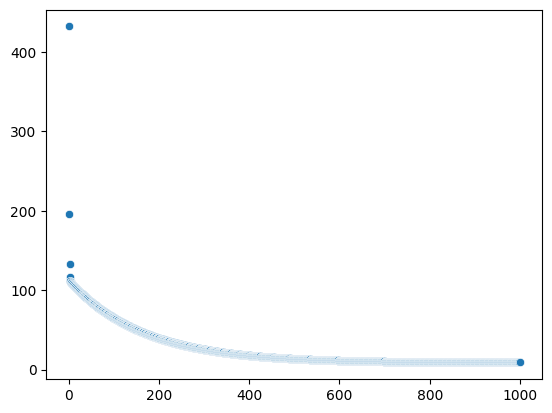

In [8]:
sns.scatterplot(x=range(num_epochs),y=losses)

<Axes: >

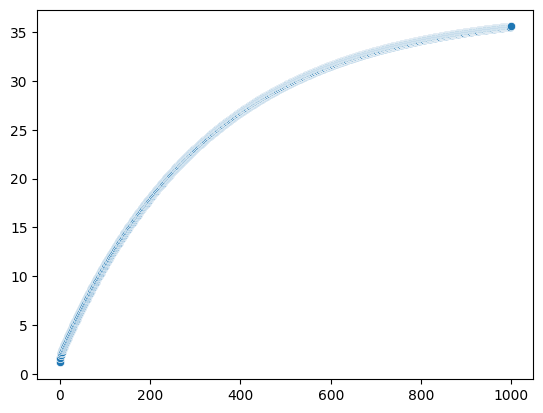

In [9]:
sns.scatterplot(x=range(num_epochs),y=bias)

<Axes: >

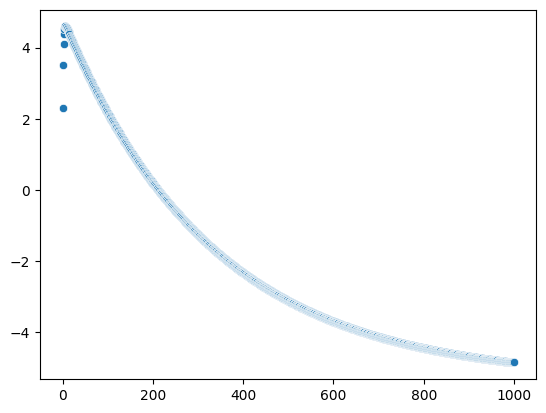

In [10]:
sns.scatterplot(x=range(num_epochs),y=slope)

<Axes: >

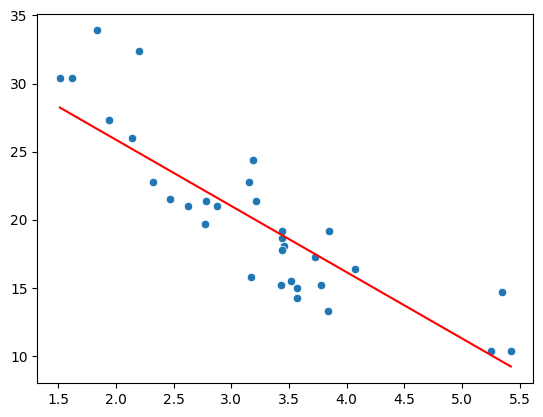

In [11]:
y_pred = model(X).data.numpy().reshape(-1)
sns.scatterplot(x=X_list , y=y_list)
sns.lineplot(x=X_list ,y=y_pred,color='red')